In [1]:
import sys
import cmath
import math
import os
import h5py
import numpy as np
from scipy.interpolate import griddata

from liblibra_core import *
import util.libutil as comn
from libra_py import units
from libra_py import data_conv
import libra_py.dynamics.tsh.compute as tsh_dynamics
import libra_py.data_savers as data_savers

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

#parent_dir = os.path.basename(os.path.dirname(os.getcwd()))
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)

from kcrpmd_utils.kcrpmdtst import KcrpmdTst
from kcrpmd_utils.kcrpmdmodel import gen_kcrpmd_bath_params, get_ABC, kcrpmd_system_bath

plt.rcParams.update({
    'figure.figsize': (4.0, 3.0),
    'figure.dpi': 300,
    'figure.facecolor': 'white',
    'figure.edgecolor': 'white',
    'lines.linewidth': 2,
    'axes.linewidth': 3,
    'axes.labelsize': 19,
    'axes.titlesize': 19,
    'xtick.direction': 'in',
    'xtick.top': True,
    'ytick.direction': 'in',
    'ytick.right': True,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.labelsize': 13.5,
    'ytick.labelsize': 13.5,
    'legend.fontsize': 11,
    'legend.frameon': False,
})

def add_hbar(ax, pi, pf, label, tick_size=0.1, label_offset=0.1, linewidth=1.5, fontsize=10):
    """
    Adds a dimension bar with tick marks and a label.

    Parameters:
        ax           : matplotlib Axes object to draw on
        pi           : starting point of the bar
        pf           : ending point of the bar
        label        : string label to annotate the bar
        tick_size    : length of the perpendicular ticks
        label_offset : distance to offset the label perpendicular to the bar
        linewidth    : width of the lines
        fontsize     : size of the label text
    """
    # Line vector
    v = (pf[0] - pi[0], pf[1] - pi[1])
    length = (v[0]**2 + v[1]**2)**(0.5)
    if length == 0:
        raise ValueError("Dimension bar must have nonzero length.")
    # Normalize direction
    u = (v[0] / length, v[1] / length)
    # Perpendicular direction (to left of the vector)
    uperp = -u[1], u[0]
    # Determine tick start positions based on direction
    pi_ti = (pi[0] - 0.5 * uperp[0] * tick_size, pi[1] - 0.5 * uperp[1] * tick_size)
    pi_tf = (pi[0] + 0.5 * uperp[0] * tick_size, pi[1] + 0.5 * uperp[1] * tick_size)
    pf_ti = (pf[0] - 0.5 * uperp[0] * tick_size, pf[1] - 0.5 * uperp[1] * tick_size)
    pf_tf = (pf[0] + 0.5 * uperp[0] * tick_size, pf[1] + 0.5 * uperp[1] * tick_size)

    # Draw main bar
    ax.plot([pi[0], pf[0]], [pi[1], pf[1]], linewidth=linewidth, color='k')
    # Draw ticks
    ax.plot([pi_ti[0], pi_tf[0]], [pi_ti[1], pi_tf[1]], linewidth=linewidth, color='k')
    ax.plot([pf_ti[0], pf_tf[0]], [pf_ti[1], pf_tf[1]], linewidth=linewidth, color='k')
    # Label position (midpoint + offset)
    pm = ((pi[0] + pf[0]) / 2, (pi[1] + pf[1]) / 2)
    plabel = (pm[0] + uperp[0] * label_offset, pm[1] + uperp[1] * label_offset)
    ax.text(plabel[0], plabel[1], label, fontsize=fontsize, color='k', ha='center', va='center')

    return ax

def add_abar(ax, pi, pf, label, mutation_scale=10, label_offset=0.1, linewidth=1.5, fontsize=10):
    """
    Adds a double-headed arrow bar with a label.

    Parameters:
        ax             : matplotlib Axes object to draw on
        pi, pf         : start and end points of the arrow bar (tuples)
        label          : text label
        label_offset   : perpendicular offset of the label from the bar
        linewidth      : width of the arrow line
        fontsize       : size of label text
        mutation_scale : size of the arrowheads
    """

    # Compute vector and unit direction
    v = (pf[0] - pi[0], pf[1] - pi[1])
    length = (v[0]**2 + v[1]**2)**0.5
    if length == 0:
        raise ValueError("Arrow bar must have nonzero length.")
    u = (v[0] / length, v[1] / length)

    # Perpendicular direction for label offset
    uperp = (-u[1], u[0])

    # Create and add double-headed arrow
    arrow = FancyArrowPatch(
        posA=pi,
        posB=pf,
        shrinkA=0,
        shrinkB=0,
        arrowstyle='<->',
        linewidth=linewidth,
        color='k',
        mutation_scale=mutation_scale
    )
    ax.add_patch(arrow)

    # Label position (midpoint + offset)
    pm = ((pi[0] + pf[0]) / 2, (pi[1] + pf[1]) / 2)
    plabel = (pm[0] + uperp[0] * label_offset, pm[1] + uperp[1] * label_offset)
    ax.text(plabel[0], plabel[1], label, fontsize=fontsize, color='k', ha='center', va='center')

    return ax


<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for boost::python::detail::container_element<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, unsigned long, boost::python::detail::final_vector_derived_policies<std::vector<std::vector<int, std::allocator<int> >, std::allocator<std::vector<int, std::allocator<int> > > >, false> > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWarning: to-Python converter for std::vector<std::vector<float, std::allocator<float> >, std::allocator<std::vector<float, std::allocator<float> > > > already registered; second conversion method ignored.
<frozen importlib._bootstrap>:228: RuntimeWar

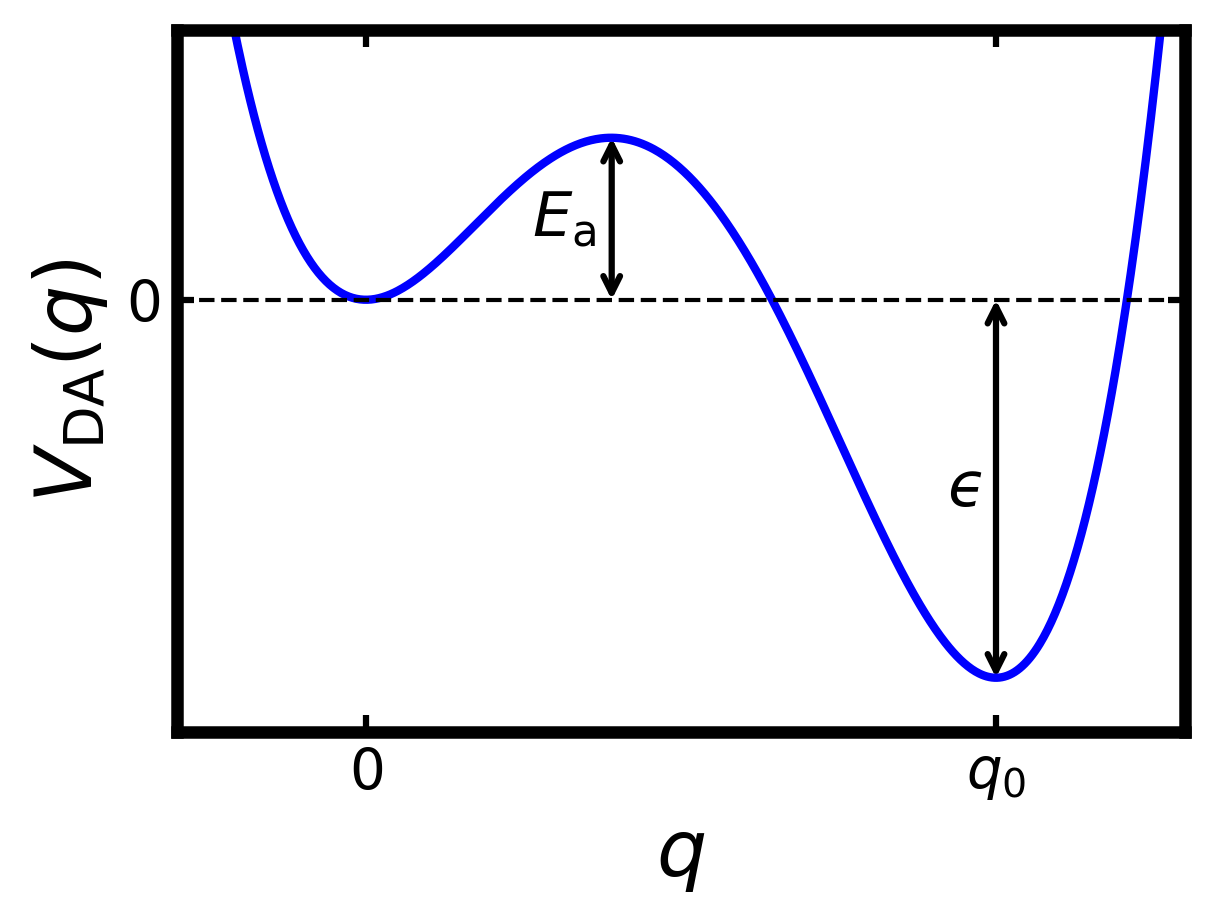

In [2]:
########################
####### FIGURE 1 #######
########################

# Numerically computing system C bias double well parameters Aq, Bq, and Cq, from q0, leps, and Ea
(A, B, C) = get_ABC(q0=1.0, leps=-7, Ea=3)
x_ar = np.linspace(-0.5, 1.5, 1000)
y_ar = A * x_ar**4 + B * x_ar**3 + C * x_ar**2

fig, ax = plt.subplots()
ax.plot(x_ar, y_ar, color='blue')
ax.axhline(y=0, color='k', linestyle='--', linewidth=1)
ax.set_xlim(-0.3,1.3)
ax.set_ylim(-8.0,5.0)
ax.set_xticks([0.0, 1.0])
ax.set_yticks([0])
ax.set_xticklabels([r'$0$', r'$q_0$'])
ax.set_xlabel(r"$q$")
ax.set_ylabel(r"$V_{\mathrm{DA}}(q)$")

ax = add_abar(ax, (1.0, -7), (1.0, 0.0), label=r'$ϵ$', mutation_scale=10, label_offset=0.05, linewidth=1.5, fontsize=15)
ax = add_abar(ax, (0.39, 0.0), (0.39, 3.0), label=r'$E_\mathrm{a}$', mutation_scale=10, label_offset=0.075, linewidth=1.5, fontsize=15)

plt.tight_layout()
plt.subplots_adjust(left=0.14, right=0.98, top=0.98, bottom=0.20)
#plt.savefig('fig1.png')
plt.show()

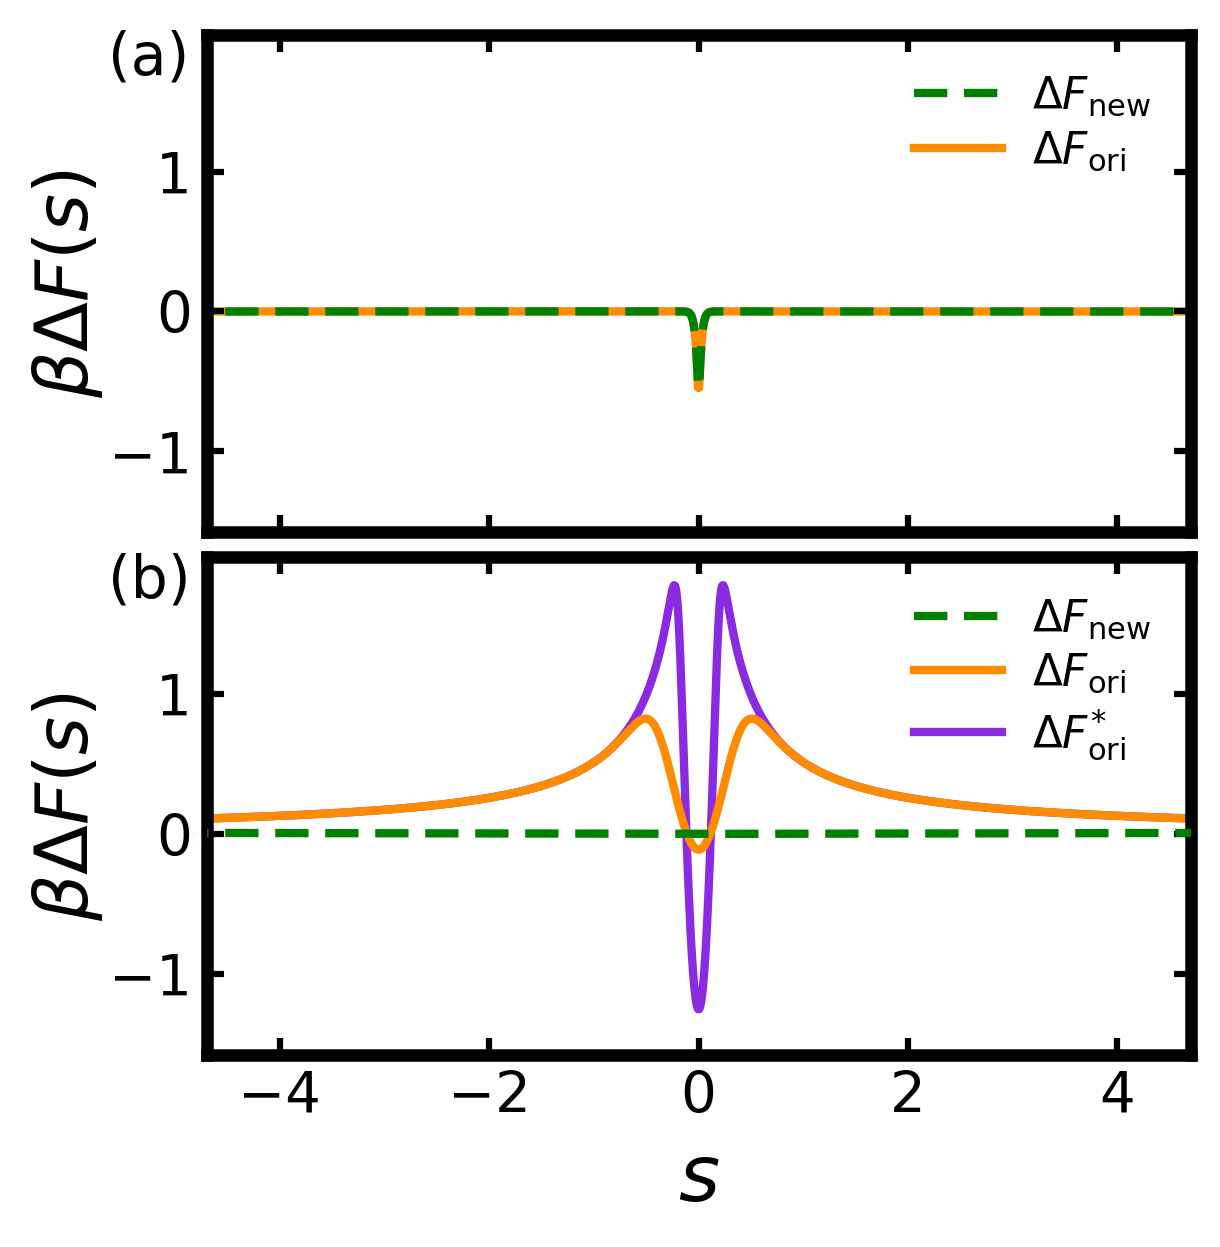

In [3]:
########################
####### FIGURE 2 #######
########################

# Setting parameters for free energy plot analysis, consistent with system A in this case.
T = 300.0
beta = units.hartree / (units.boltzmann * T)
a = 0.1
b = 1000.0
c = 1.0

ms = 1836.0
ws = 2.28e-3
s0 = -2.4
s1 = 2.4
eps = 0.0

# Setting coupling constant values for free energy comparison in the two limiting cases
K0_low = 9.55e-05
K0_high = 4.75e-03
bq = 0.0
mq = 5e4
wq = 5e-4

# Functional forms of diabatic coupling and donor-acceptor potential to be used in KC-RPMD TST code
Kq_low = lambda q: K0_low * np.exp(-bq * q)
Kq_high = lambda q: K0_high * np.exp(-bq * q)
Vq = lambda q: 0.5 * mq * wq**2 * q**2

# Initializing TST objects for adiabtic, new implementation KC-RPMD, and old implementation KC-RPMD
# at low diabatic coupling
adiabatic_tst_low = KcrpmdTst(beta,a,b,c,ms,ws,s0,s1,eps,Kq_low,Vq) 
newkcrpmd_tst_low = KcrpmdTst(beta,a,b,c,ms,ws,s0,s1,eps,Kq_low,Vq); newkcrpmd_tst_low.set_eta_my_gammay() 
oldkcrpmd_tst_low = KcrpmdTst(beta,a,b,c,ms,ws,s0,s1,eps,Kq_low,Vq); oldkcrpmd_tst_low.set_eta_my_gammay()
oldkcrpmd_tst_low.eta = 2 * oldkcrpmd_tst_low.eta - np.sqrt(np.pi / oldkcrpmd_tst_low.a)
oldkcrpmd_tst_low.a = 2 * oldkcrpmd_tst_low.a; oldkcrpmd_tst_low.c = 0.0

# Initializing TST objects for adiabtic, new implementation KC-RPMD, old implementation KC-RPMD,
# and old implementation with a<=1.0 criteria at high diabatic coupling
adiabatic_tst_high = KcrpmdTst(beta,a,b,c,ms,ws,s0,s1,eps,Kq_high,Vq) 
newkcrpmd_tst_high = KcrpmdTst(beta,a,b,c,ms,ws,s0,s1,eps,Kq_high,Vq); newkcrpmd_tst_high.set_eta_my_gammay() 
oldkcrpmd_tst_high = KcrpmdTst(beta,a,b,c,ms,ws,s0,s1,eps,Kq_high,Vq); oldkcrpmd_tst_high.set_eta_my_gammay()
oldkcrpmd_tst_high.eta = 2 * oldkcrpmd_tst_high.eta - np.sqrt(np.pi / oldkcrpmd_tst_high.a)
oldkcrpmd_tst_high.a = 2 * oldkcrpmd_tst_high.a; oldkcrpmd_tst_high.c = 0.0
oldkcrpmda1_tst_high = KcrpmdTst(beta,1.0,b,c,ms,ws,s0,s1,eps,Kq_high,Vq); oldkcrpmda1_tst_high.set_eta_my_gammay()
oldkcrpmda1_tst_high.eta = 2 * oldkcrpmda1_tst_high.eta - np.sqrt(np.pi / oldkcrpmda1_tst_high.a)
oldkcrpmda1_tst_high.a = 2 * oldkcrpmda1_tst_high.a; oldkcrpmda1_tst_high.c = 0.0

# Creating array to scan along s coordinate, then computing free energies for each TST object
s_ar = np.linspace(-5.0, 5.0, 1000)

Fgs_low = adiabatic_tst_low.Fgs(s_ar)
newFs_low = newkcrpmd_tst_low.Fs(s_ar)
oldFs_low = oldkcrpmd_tst_low.Fs(s_ar)

Fgs_high = adiabatic_tst_high.Fgs(s_ar)
newFs_high = newkcrpmd_tst_high.Fs(s_ar)
oldFs_high = oldkcrpmd_tst_high.Fs(s_ar)
oldFsa1_high = oldkcrpmda1_tst_high.Fs(s_ar)

# Final plots show thermally weighted free energy difference between KC-RPMD and the ground adiabat potential
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(4.0, 4.0), sharex=True, sharey=False, dpi=300)
ax1.text(-0.1, 0.92, "(a)", transform=ax1.transAxes, fontsize=14)
ax2.text(-0.1, 0.92, "(b)", transform=ax2.transAxes, fontsize=14)
ax1.plot(s_ar, beta * (newFs_low - Fgs_low), color='g', label='$\Delta F_{\mathrm{new}}$', dashes=[4, 2], zorder=2)
ax1.plot(s_ar, beta * (oldFs_low - Fgs_low), color='darkorange', label='$\Delta F_{\mathrm{ori}}$', zorder=1)
ax2.plot(s_ar, beta * (newFs_high - Fgs_high), color='g', label='$\Delta F_{\mathrm{new}}$', dashes=[4, 2], zorder=3)
ax2.plot(s_ar, beta * (oldFs_high - Fgs_high), color='darkorange', label=r'$\Delta F_{\mathrm{ori}}$', zorder=2)
ax2.plot(s_ar, beta * (oldFsa1_high - Fgs_high), color='blueviolet', label=r'$\Delta F_{\mathrm{ori}}^{*}$', zorder=1)
ax1.set_xlim(-4.7,4.7)
ax1.set_ylim(-1.58, 1.98)
ax2.set_ylim(-1.58, 1.98)
ax1.set_yticks([-1, 0, 1])
ax2.set_xticks([-4, -2, 0, 2, 4])
ax2.set_yticks([-1, 0, 1])
ax2.set_xlabel(r"$s$")
ax1.set_ylabel(r"$\beta\Delta F(s)$", labelpad=1, fontsize = 17.5)
ax2.set_ylabel(r"$\beta\Delta F(s)$", labelpad=1, fontsize = 17.5)
ax1.legend(fontsize=10.5, loc='upper right', handletextpad=0.7, labelspacing=0.25)
ax2.legend(fontsize=10.5, loc='upper right', handletextpad=0.7, labelspacing=0.25)

plt.subplots_adjust(hspace=0.05, left=0.16, right=0.98, top=0.98, bottom=0.13)
#plt.savefig('fig2.png')
plt.show()

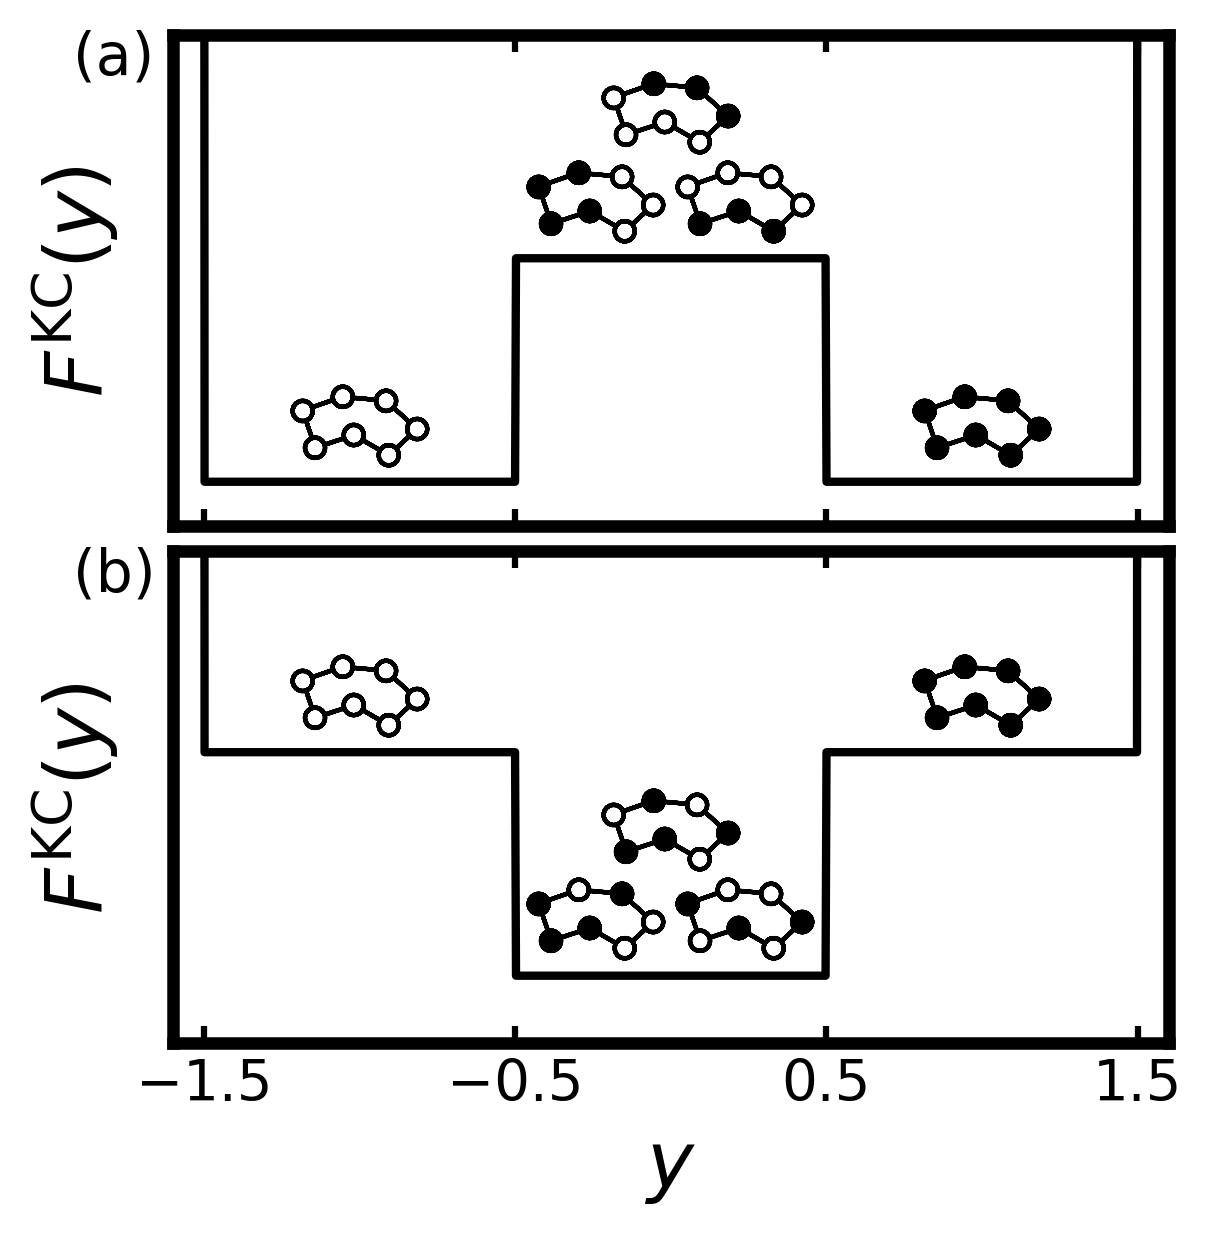

In [4]:
########################
####### FIGURE 3 #######
########################

# Qualitative plot of free energy along y at different coupling strengths. inf is just a large number,
# hnad1 is the height of the kinked-pair region at small coupling and hnad2 at large coupling.
inf = 10.
x_ar = np.linspace(-1.51, 1.51, 1000)
hnad1 = 1.
hnad2 = -1.
y_ar1 = (inf * (1 - np.heaviside(x_ar + 1.5, 0.5) + np.heaviside(x_ar - 1.5, 0.5))
         + hnad1 * (np.heaviside(x_ar + 0.5, 0.5) - np.heaviside(x_ar - 0.5, 0.5))) 
y_ar2 = (inf * (1 - np.heaviside(x_ar + 1.5, 0.5) + np.heaviside(x_ar - 1.5, 0.5))
         + hnad2 * (np.heaviside(x_ar + 0.5, 0.5) - np.heaviside(x_ar - 0.5, 0.5))) 

# Loading in ring polymer graphics
rp_0 = plt.imread("ring_polymers/rp_0.png")
rp_1 = plt.imread("ring_polymers/rp_1.png")
rp_kp1 = plt.imread("ring_polymers/rp_kp1.png")
rp_kp2 = plt.imread("ring_polymers/rp_kp2.png")
rp_kp3 = plt.imread("ring_polymers/rp_kp3.png")
rp_kp4 = plt.imread("ring_polymers/rp_kp4.png")
rp_kp5 = plt.imread("ring_polymers/rp_kp5.png")
rp_kp6 = plt.imread("ring_polymers/rp_kp6.png")
ib_0 = OffsetImage(rp_0, zoom=0.05)
ib_1 = OffsetImage(rp_1, zoom=0.05)
ib_kp1 = OffsetImage(rp_kp1, zoom=0.05)
ib_kp2 = OffsetImage(rp_kp2, zoom=0.05)
ib_kp3 = OffsetImage(rp_kp3, zoom=0.05)
ib_kp4 = OffsetImage(rp_kp4, zoom=0.05)
ib_kp5 = OffsetImage(rp_kp5, zoom=0.05)
ib_kp6 = OffsetImage(rp_kp6, zoom=0.05)
ab1_0 = AnnotationBbox(ib_0, (-1.0, 0.25), frameon=False)
ab1_1 = AnnotationBbox(ib_1, (1.0, 0.25), frameon=False)
ab1_kp1 = AnnotationBbox(ib_kp1, (0.0, 1.65), frameon=False)
ab1_kp2 = AnnotationBbox(ib_kp2, (-0.24, 1.25), frameon=False)
ab1_kp3 = AnnotationBbox(ib_kp3, (0.24, 1.25), frameon=False)
ab2_0 = AnnotationBbox(ib_0, (-1.0, 0.25), frameon=False)
ab2_1 = AnnotationBbox(ib_1, (1.0, 0.25), frameon=False)
ab2_kp4 = AnnotationBbox(ib_kp4, (0.0, -0.35), frameon=False)
ab2_kp5 = AnnotationBbox(ib_kp5, (-0.24, -0.75), frameon=False)
ab2_kp6 = AnnotationBbox(ib_kp6, (0.24, -0.75), frameon=False)

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(4.0, 4.0), sharex=True, sharey=False, dpi=300)
ax1.add_artist(ab1_0)
ax1.add_artist(ab1_1)
ax1.add_artist(ab1_kp1)
ax1.add_artist(ab1_kp2)
ax1.add_artist(ab1_kp3)
ax2.add_artist(ab2_0)
ax2.add_artist(ab2_1)
ax2.add_artist(ab2_kp4)
ax2.add_artist(ab2_kp5)
ax2.add_artist(ab2_kp6)
ax1.text(-0.1, 0.92, "(a)", transform=ax1.transAxes, fontsize=14)
ax2.text(-0.1, 0.92, "(b)", transform=ax2.transAxes, fontsize=14)
ax1.plot(x_ar, y_ar1, color='k', label='data1')
ax2.plot(x_ar, y_ar2, color='k', label='data2')
ax1.set_xlim(-1.6,1.6)
ax1.set_ylim(-0.2,2.0)
ax2.set_ylim(-1.3,0.9)
ax1.set_xticks([-1.5, -0.5, 0.5, 1.5])
ax1.set_yticks([])
ax2.set_yticks([])
ax2.set_xlabel(r"$y$")
ax1.set_ylabel(r"$F^{\mathrm{KC}}(y)$", labelpad=12.5)
ax2.set_ylabel(r"$F^{\mathrm{KC}}(y)$", labelpad=12.5)
ax1.set_title("")

plt.subplots_adjust(hspace=0.05, left=0.15, right=0.98, top=0.98, bottom=0.14)
#plt.savefig('fig3.png')
plt.show()


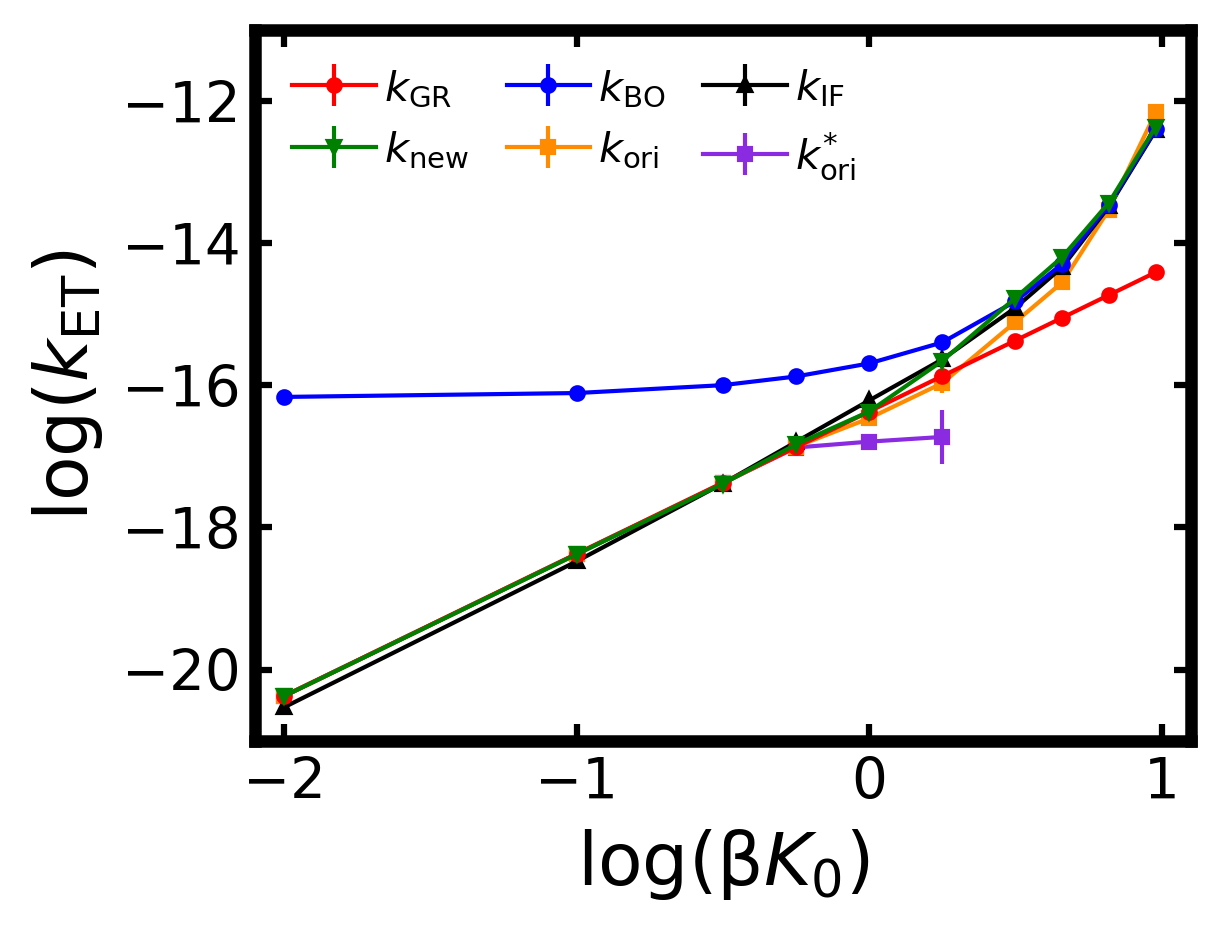

In [28]:
########################
####### FIGURE 4 #######
########################

# Reading in directories for system 1 (system A)
adiabatic_fix_s = sorted([d for d in os.listdir('../_sys_A/adiabatic') if d.startswith('_fix_s')], key=lambda s: float(s.split("logK_")[1]))
kcrpmd_ori_fix_s = sorted([d for d in os.listdir('../_sys_A/kcrpmd_ori') if d.startswith('_fix_s_a_0.1')], key=lambda s: float(s.split("logK_")[1]))
kcrpmd_ori_fix_y = sorted([d for d in os.listdir('../_sys_A/kcrpmd_ori') if d.startswith('_fix_y_a_0.1')], key=lambda s: float(s.split("logK_")[1]))
kcrpmd_ori_fix_s_a_1 = sorted([d for d in os.listdir('../_sys_A/kcrpmd_ori') if d.startswith('_fix_s') and "_a_0.1" not in d], key=lambda s: float(s.split("logK_")[1]))
kcrpmd_ori_fix_s_a_1 = kcrpmd_ori_fix_s[:int(len(kcrpmd_ori_fix_s)-len(kcrpmd_ori_fix_s_a_1))] + kcrpmd_ori_fix_s_a_1
kcrpmd_ori_fix_y_a_1 = sorted([d for d in os.listdir('../_sys_A/kcrpmd_ori') if d.startswith('_fix_y') and "_a_0.1" not in d], key=lambda s: float(s.split("logK_")[1]))
kcrpmd_ori_fix_y_a_1 = kcrpmd_ori_fix_y[:int(len(kcrpmd_ori_fix_y)-len(kcrpmd_ori_fix_y_a_1))] + kcrpmd_ori_fix_y_a_1
kcrpmd_new_fix_s = sorted([d for d in os.listdir('../_sys_A/kcrpmd_new') if d.startswith('_fix_s')], key=lambda s: float(s.split("logK_")[1]))
kcrpmd_new_fix_y = sorted([d for d in os.listdir('../_sys_A/kcrpmd_new') if d.startswith('_fix_y')], key=lambda s: float(s.split("logK_")[1]))

with open("../_sys_A/adiabatic/" + adiabatic_fix_s[0] + "/_model_params.txt") as f:
    model_params = eval(f.read())

with open("../_sys_A/adiabatic/" + adiabatic_fix_s[0] + "/_control_params_dynamics.txt") as f:
    control_params = eval(f.read())

beta = units.hartree / (units.boltzmann * control_params["Temperature"])

# From directory names, create array for log(beta*K0) diabatic coupling prefactor parameter
logK_arr = np.array([key.split('_')[4] for key in adiabatic_fix_s], dtype=float)[1:]

# Initialize data arrays for golden rule rate, Born-Oppenheimer rate, interpolation formula,
# old implementation KC-RPMD rates, new KC-RPMD implementation rates, and standard errors for all rates.
kGR_arr = np.zeros(logK_arr.shape)
kBO_arr = np.zeros(logK_arr.shape)
kBO_se_arr = np.zeros(logK_arr.shape)
kIF_arr = np.zeros(logK_arr.shape)
kIF_se_arr = np.zeros(logK_arr.shape)
kori_arr = np.zeros(logK_arr.shape)
kori_se_arr = np.zeros(logK_arr.shape)
koria1_arr = np.zeros(logK_arr.shape)
koria1_se_arr = np.zeros(logK_arr.shape)
knew_arr = np.zeros(logK_arr.shape)
knew_se_arr = np.zeros(logK_arr.shape)

# Reading in and computing Born-Oppenheimer rates for K0=0
ktst0 = np.loadtxt("../_sys_A/adiabatic/" + adiabatic_fix_s[0] + "/tst_data/ktsts.txt")
kappa0_se = np.loadtxt("../_sys_A/adiabatic/" + adiabatic_fix_s[0] + "/kappa_data/kappa_se.txt")[-1]
kappa0_avg = np.loadtxt("../_sys_A/adiabatic/" + adiabatic_fix_s[0] + "/kappa_data/kappa_avg.txt")[-1]
kBO0_se = ktst0 * kappa0_se
kBO0 = ktst0 * kappa0_avg

# Computing reference rate theories kGR, KBO, and kIF
for i, d in enumerate(adiabatic_fix_s[1:]):
    kGR_arr[i] = np.loadtxt("../_sys_A/adiabatic/" + adiabatic_fix_s[i+1] + "/tst_data/kGR.txt")
    kBO_arr[i] = np.loadtxt("../_sys_A/adiabatic/" + adiabatic_fix_s[i+1] + "/tst_data/ktsts.txt")
    kBO_se_arr[i] = kBO_arr[i] * np.loadtxt("../_sys_A/adiabatic/" + adiabatic_fix_s[i+1] + "/kappa_data/kappa_se.txt")[-1]
    kBO_arr[i] *= np.loadtxt("../_sys_A/adiabatic/" + adiabatic_fix_s[i+1] + "/kappa_data/kappa_avg.txt")[-1]
    kIF_arr[i] = kGR_arr[i] * kBO_arr[i] / (kGR_arr[i] + kBO0)
    kIF_se_arr[i] = kIF_arr[i] * kBO_se_arr[i] / kBO_arr[i]

# Computing old and new implementation KC-RPMD rates at a=0.1 using y coordinate for first 5 K0 points
# and s coordinate for last 5 points.
for i in range(5):
    kori_arr[i] = np.loadtxt("../_sys_A/kcrpmd_ori/" + kcrpmd_ori_fix_y[i] + "/tst_data/ktsty.txt")
    kori_se_arr[i] = kori_arr[i] * np.loadtxt("../_sys_A/kcrpmd_ori/" + kcrpmd_ori_fix_y[i] + "/kappa_data/kappa_se.txt")[-1]
    kori_arr[i] *= np.loadtxt("../_sys_A/kcrpmd_ori/" + kcrpmd_ori_fix_y[i] + "/kappa_data/kappa_avg.txt")[-1]
    knew_arr[i] = np.loadtxt("../_sys_A/kcrpmd_new/" + kcrpmd_new_fix_y[i] + "/tst_data/ktsty.txt")
    knew_se_arr[i] = knew_arr[i] * np.loadtxt("../_sys_A/kcrpmd_new/" + kcrpmd_new_fix_y[i] + "/kappa_data/kappa_se.txt")[-1]
    knew_arr[i] *= np.loadtxt("../_sys_A/kcrpmd_new/" + kcrpmd_new_fix_y[i] + "/kappa_data/kappa_avg.txt")[-1]
for i in range(5,10):
    kori_arr[i] = np.loadtxt("../_sys_A/kcrpmd_ori/" + kcrpmd_ori_fix_s[i] + "/tst_data/ktsts.txt")
    kori_se_arr[i] = kori_arr[i] * np.loadtxt("../_sys_A/kcrpmd_ori/" + kcrpmd_ori_fix_s[i] + "/kappa_data/kappa_se.txt")[-1]
    kori_arr[i] *= np.loadtxt("../_sys_A/kcrpmd_ori/" + kcrpmd_ori_fix_s[i] + "/kappa_data/kappa_avg.txt")[-1]
    knew_arr[i] = np.loadtxt("../_sys_A/kcrpmd_new/" + kcrpmd_new_fix_s[i] + "/tst_data/ktsts.txt")
    knew_se_arr[i] = knew_arr[i] * np.loadtxt("../_sys_A/kcrpmd_new/" + kcrpmd_new_fix_s[i] + "/kappa_data/kappa_se.txt")[-1]
    knew_arr[i] *= np.loadtxt("../_sys_A/kcrpmd_new/" + kcrpmd_new_fix_s[i] + "/kappa_data/kappa_avg.txt")[-1]

# Computing old implementation KC-RPMD rates with a<=1.0 criteria using y coordinate for first 7 K0 points.
# last 3 points are not plotted, rates are ill-defined for these points, see thermalization.png and transmission.png
for i in range(7):
    koria1_arr[i] = np.loadtxt("../_sys_A/kcrpmd_ori/" + kcrpmd_ori_fix_y_a_1[i] + "/tst_data/ktsty.txt")
    koria1_se_arr[i] = koria1_arr[i] * np.loadtxt("../_sys_A/kcrpmd_ori/" + kcrpmd_ori_fix_y_a_1[i] + "/kappa_data/kappa_se.txt")[-1]
    koria1_arr[i] *= np.loadtxt("../_sys_A/kcrpmd_ori/" + kcrpmd_ori_fix_y_a_1[i] + "/kappa_data/kappa_avg.txt")[-1]
for i in range(7,10):
    koria1_arr[i] = np.loadtxt("../_sys_A/kcrpmd_ori/" + kcrpmd_ori_fix_s_a_1[i] + "/tst_data/ktsts.txt")
    koria1_se_arr[i] = koria1_arr[i] * np.loadtxt("../_sys_A/kcrpmd_ori/" + kcrpmd_ori_fix_s_a_1[i] + "/kappa_data/kappa_se.txt")[-1]
    koria1_arr[i] *= np.loadtxt("../_sys_A/kcrpmd_ori/" + kcrpmd_ori_fix_s_a_1[i] + "/kappa_data/kappa_avg.txt")[-1]

fig, ax = plt.subplots()
ax.errorbar(logK_arr, np.log10(kGR_arr), kGR_arr*0, fmt='o-', markersize=3, linewidth=1, color='r', label=r'$k_\mathrm{GR}$', zorder=5)
ax.errorbar(logK_arr, np.log10(knew_arr), knew_se_arr / (knew_arr * np.log(10)), fmt='v-', markersize=3, linewidth=1, color='g', label=r'$k_\mathrm{new}$', zorder=6)
ax.errorbar(logK_arr, np.log10(kBO_arr), kBO_se_arr / (kBO_arr * np.log(10)), fmt='o-', markersize=3, linewidth=1, color='b', label=r'$k_\mathrm{BO}$', zorder=4)
ax.errorbar(logK_arr, np.log10(kori_arr), kori_se_arr / (kori_arr * np.log(10)), fmt='s-', markersize=3, linewidth=1, color='darkorange', label=r'$k_\mathrm{ori}$', zorder=2)
ax.errorbar(logK_arr, np.log10(kIF_arr), kIF_se_arr / (kIF_arr * np.log(10)), fmt='^-', markersize=3, linewidth=1, color='k', label=r'$k_\mathrm{IF}$', zorder=3)
ax.errorbar(logK_arr[:7], np.log10(koria1_arr[:7]), koria1_se_arr[:7] / (koria1_arr[:7] * np.log(10)), fmt='s-', markersize=3, linewidth=1, color='blueviolet', label=r'$k_\mathrm{ori}^{*}$', zorder=1)
ax.set_xlim(-2.1,1.1)
ax.set_ylim(-21.0,-11.0)
ax.set_xticks([-2, -1, 0, 1])
ax.set_yticks([-20, -18, -16, -14, -12])
ax.set_xlabel(r"log(β$K_0$)", fontsize = 17.5)
ax.set_ylabel(r"log($k_{\mathrm{ET}}$)", fontsize = 17.5)
ax.legend(ncol=3, fontsize=10, loc='upper left', handletextpad=0.2,  columnspacing=0.9)

plt.subplots_adjust(left=0.20, right=0.98, top=0.98, bottom=0.19)
#plt.savefig('fig4.png')
plt.show()
